# Compute statistics on scores

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ir_rpp.preprocessing import load_labels_and_runs, dataset_summary
from ir_rpp.scores import evaluate_preferences, aggregate_preferences
from ir_rpp.statistical_tests import run_ttests, run_tukeys_hsd_test

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load datasets

In [4]:
qrels, runs = load_labels_and_runs("libraryThing", binary_relevance=4)

Reading run files: 100%|██████████| 21/21 [00:16<00:00,  1.31it/s]


In [5]:
dataset_summary(qrels, runs)

requests                  7227
runs                        21
rel/request          13.146811
subtopics/request         todo
dtype: object

## Compute scores and score differences

In [6]:
METRICS = ["rpp", "invrpp", "dcgrpp", "ap", "ndcg", "rr"]

In [7]:
summary, preferences, raw_metrics = evaluate_preferences(
    qrels = qrels,
    runs=runs,
    measures=METRICS,
    query_eval_wanted=True
)

Iterating over qids:   0%|          | 0/7227 [00:00<?, ?it/s]

In [ ]:
df_preferences = pd.DataFrame(preferences)

,qid,runi,runj,sample,type,rpp,invrpp,dcgrpp,ap,ndcg,rr,run
0,0,LM-WSR-UB,CHI2,0,preference,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
1,0,LM-WSR-UB,Pop,0,preference,0.5,0.666667,0.613147,0.481481,0.485604,0.962963,NaN
2,0,LM-WSR-UB,NNCosNgbr-IB,0,preference,0.5,0.666667,0.613147,0.250000,0.226294,0.500000,NaN
3,0,LM-WSR-UB,PureSVD,0,preference,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
4,0,LM-WSR-UB,RM2,0,preference,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1669432,7278,NaN,NaN,0,metric,NaN,NaN,NaN,0.000000,0.000000,0.000000,RM1
1669433,7278,NaN,NaN,0,metric,NaN,NaN,NaN,0.000000,0.000000,0.000000,Random
1669434,7278,NaN,NaN,0,metric,NaN,NaN,NaN,0.041667,0.139056,0.166667,LM-WSR-IB
1669435,7278,NaN,NaN,0,metric,NaN,NaN,NaN,0.015625,0.095507,0.062500,RSV


In [ ]:
pref_eval_output = summary + preferences + raw_metrics
system_orderings_by_query, system_orderings = aggregate_preferences(prefs=pref_eval_output, query_eval_wanted=True)

In [102]:
def get_ordering(system_orderings, metric):
    ordering = system_orderings[metric]
    if isinstance(ordering, dict):
        ordering = ordering.get('mean') or ordering.get('mc4')
    return ordering

In [62]:
from scipy.stats import kendalltau

def run_kendal_tau(a: list[str], b: list[str]):
    rank_a = {item: i for i, item in enumerate(a)}
    b_as_ranks = [rank_a[item] for item in b]
    a_ranks = list(range(len(a)))
    tau, p_value = kendalltau(a_ranks, b_as_ranks)
    return tau, p_value

In [ ]:
for i, metric1 in enumerate(METRICS):
    for metric2 in METRICS[i + 1 :]:
        tau, p_value = run_kendal_tau(
            get_ordering(system_orderings, metric1),
            get_ordering(system_orderings, metric2),
        )
        print(f" {metric1.upper():<7} vs {metric2.upper():<7} : {tau:.2f}")

 RPP     vs INVRPP  : 1.00
 RPP     vs DCGRPP  : 1.00
 RPP     vs AP      : 0.92
 RPP     vs NDCG    : 0.92
 RPP     vs RR      : 0.89
 INVRPP  vs DCGRPP  : 1.00
 INVRPP  vs AP      : 0.92
 INVRPP  vs NDCG    : 0.92
 INVRPP  vs RR      : 0.89
 DCGRPP  vs AP      : 0.92
 DCGRPP  vs NDCG    : 0.92
 DCGRPP  vs RR      : 0.89
 AP      vs NDCG    : 1.00
 AP      vs RR      : 0.94
 NDCG    vs RR      : 0.94


In [118]:
QUERY_ID = 3
for i, metric1 in enumerate(METRICS):
    for metric2 in METRICS[i + 1 :]:
        tau, p_value = run_kendal_tau(
            get_ordering(system_orderings_by_query[QUERY_ID], metric1),
            get_ordering(system_orderings_by_query[QUERY_ID],metric2),
        )
        print(f" {metric1.upper():<7} vs {metric2.upper():<7} : {tau:.2f}")

 RPP     vs INVRPP  : 0.90
 RPP     vs DCGRPP  : 0.95
 RPP     vs AP      : 0.92
 RPP     vs NDCG    : 0.97
 RPP     vs RR      : 0.55
 INVRPP  vs DCGRPP  : 0.94
 INVRPP  vs AP      : 0.93
 INVRPP  vs NDCG    : 0.90
 INVRPP  vs RR      : 0.66
 DCGRPP  vs AP      : 0.95
 DCGRPP  vs NDCG    : 0.94
 DCGRPP  vs RR      : 0.60
 AP      vs NDCG    : 0.91
 AP      vs RR      : 0.59
 NDCG    vs RR      : 0.56


## Correlation with existing metrics

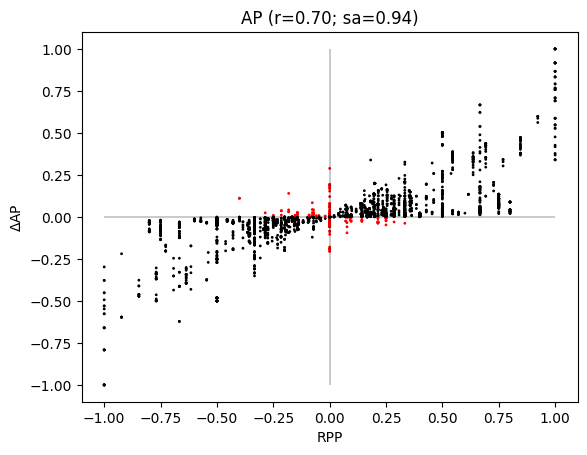

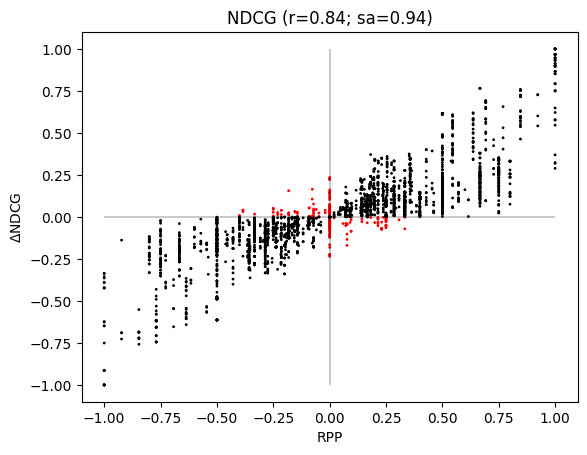

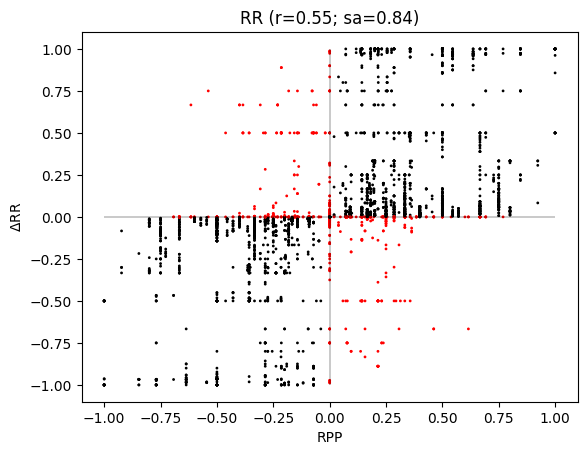

In [ ]:
QUERY_IDS = [str(i) for i in range(20)]
df_query_level_diffs = df_preferences[df_preferences["qid"].apply(lambda qid: qid in QUERY_IDS)]
rpp = df_query_level_diffs["rpp"]
for metric_name in df_query_level_diffs.columns:
    metric = df_query_level_diffs[metric_name]
    if "rpp" not in metric_name and metric_name in METRICS:
        do_agree = np.sign(rpp) == np.sign(metric)
        fig, ax = plt.subplots()
        ax.scatter(
            rpp, metric, c=["black" if agree else "red" for agree in do_agree], s=1
        )
        ax.vlines(x=0, ymin=-1, ymax=1, color="black", linewidth=0.3)
        ax.hlines(y=0, xmin=-1, xmax=1, color="black", linewidth=0.3)
        ax.set_xlabel("RPP")
        ax.set_ylabel("$\\Delta$" + metric_name.upper())

        ax.set_title(
            metric_name.upper() + f" (r={np.corrcoef(rpp, metric)[0,1]:.2f}; sa={sum(do_agree)/len(do_agree):.2f})"
        )
    plt.show()

## Robustness to incomplete data

## Discriminative Power

In [81]:
df_ttest, df_summary = run_ttests(pd.DataFrame(preferences))
df_summary

metric,rpp,invrpp,dcgrpp,ap,ndcg,rr
significant,97.62,98.57,98.1,96.19,98.1,93.81


In [103]:
df_ttest_hsd, df_summary_hsd = run_tukeys_hsd_test(pd.DataFrame(preferences))
df_summary_hsd

Comparing Pairs: 100%|██████████| 210/210 [00:00<00:00, 76919.38it/s]


metric,rpp,invrpp,dcgrpp,ap,ndcg,rr
significant,94.76,94.76,94.76,95.24,94.76,93.81


# TODO: get system orderings

In [97]:
preferences

[{'qid': '0',
  'runi': 'LM-WSR-UB',
  'runj': 'CHI2',
  'sample': 0,
  'type': 'preference',
  'rpp': 0.0,
  'invrpp': 0.0,
  'dcgrpp': 0.0,
  'ap': 0.0,
  'ndcg': 0.0,
  'rr': 0.0},
 {'qid': '0',
  'runi': 'LM-WSR-UB',
  'runj': 'Pop',
  'sample': 0,
  'type': 'preference',
  'rpp': 0.5,
  'invrpp': 0.6666666666666666,
  'dcgrpp': 0.6131471927654584,
  'ap': 0.4814814814814815,
  'ndcg': 0.4856036261458703,
  'rr': 0.962962962962963},
 {'qid': '0',
  'runi': 'LM-WSR-UB',
  'runj': 'NNCosNgbr-IB',
  'sample': 0,
  'type': 'preference',
  'rpp': 0.5,
  'invrpp': 0.6666666666666666,
  'dcgrpp': 0.6131471927654584,
  'ap': 0.25,
  'ndcg': 0.22629438553091677,
  'rr': 0.5},
 {'qid': '0',
  'runi': 'LM-WSR-UB',
  'runj': 'PureSVD',
  'sample': 0,
  'type': 'preference',
  'rpp': 0.0,
  'invrpp': 0.0,
  'dcgrpp': 0.0,
  'ap': 0.0,
  'ndcg': 0.0,
  'rr': 0.0},
 {'qid': '0',
  'runi': 'LM-WSR-UB',
  'runj': 'RM2',
  'sample': 0,
  'type': 'preference',
  'rpp': 0.0,
  'invrpp': 0.0,
  'dcgrpp

In [ ]:
# #!/usr/bin/env python3.9
# import sys
# import argparse
# import aggregation.rank_aggregation as rank_aggregation
# from measures.measures import is_metric
# import json
# import random
# from .util.pref_io import read_metrics
# from .util.pref_io import read_all_measure_names
# from .util.pref_io import read_prefs
# from .util.pref_io import read_qids
# from .util.pref_io import get_query_rankings_from_preferences
# from .util.pref_io import get_query_rankings_from_metrics
# from .util.pref_io import Preferences
# from .util.pref_io import Metrics
# from .util.pref_io import Rankings

parser: argparse.ArgumentParser = argparse.ArgumentParser(sys.argv[0])
parser.add_argument("--prefs", "-P", dest="prefs", help="prefs path", required=True)
parser.add_argument(
    "--query_eval_wanted",
    "-q",
    dest="query_eval_wanted",
    help="generate per-query results",
    action="store_true",
    default=False,
)
parser.add_argument(
    "--nosummary",
    "-n",
    dest="nosummary",
    help="suppress the summary",
    action="store_true",
    default=False,
)
parser.add_argument(
    "--query_fraction",
    dest="query_fraction",
    help="fraction of queries to preserve (default = 1.0)",
    type=float,
    default=1.0,
)
parser.add_argument("--num_samples", type=int, default=1)
parser.add_argument(
    "--measure",
    "-m",
    action="append",
    help="metric or preference name to aggregate (default: all measures in the preferences file)",
)
args = parser.parse_args()
measures = []
if args.measure is not None:
    measures += args.measure

qids = read_qids(args.prefs) if (args.query_fraction < 1.0) else None
sample_size = (
    max(1, int(len(qids) * args.query_fraction))
    if (args.query_fraction < 1.0)
    else None
)

for sample in range(args.num_samples):
    sample_qids = None if qids is None else random.sample(qids, sample_size)

    src_sample = 0 if (args.query_fraction < 1.0) else sample

    if len(measures) == 0:
        measures = read_all_measure_names(args.prefs)

    prefs: Preferences = read_prefs(args.prefs, measures, src_sample, sample_qids)
    metrics: Metrics = read_metrics(args.prefs, measures, src_sample, sample_qids)
    if sample_qids is None:
        sample_qids = list(prefs.keys())

    p_rankings: Rankings = get_query_rankings_from_preferences(prefs)
    m_rankings: Rankings = get_query_rankings_from_metrics(metrics)
    if args.query_eval_wanted:
        for qid in sample_qids:
            output_object = {}
            output_object["qid"] = qid
            output_object["sample"] = sample
            for kk, vv in p_rankings[qid].items():
                output_object[kk] = vv
            for kk, vv in m_rankings[qid].items():
                output_object[kk] = vv
            print(json.dumps(output_object))

    if not args.nosummary:
        output_object = {}
        output_object["qid"] = "all"
        output_object["sample"] = sample
        for measure in measures:
            output_object[measure] = {}
            if is_metric(measure):
                output_object[measure]["type"] = "metric"
                avgmeasure = {}
                numq = float(len(metrics))
                for qid, v in metrics.items():
                    for run, value in v[measure].items():
                        if run not in avgmeasure:
                            avgmeasure[run] = 0.0
                        avgmeasure[run] += value / numq
                ranking = [
                    x[1]
                    for x in sorted(
                        [[v, k] for k, v in avgmeasure.items()], reverse=True
                    )
                ]
                output_object[measure]["mean"] = ranking
            else:
                output_object[measure]["type"] = "preference"
                rankings_metric: list[list[str]] = []
                for qid, v in p_rankings.items():
                    rankings_metric.append(v[measure])
                output_object[measure]["mc4"] = rank_aggregation.mc4(
                    rankings_metric
                )
                output_object[measure]["borda"] = rank_aggregation.borda(
                    rankings_metric
                )
        print(json.dumps(output_object))
